# Phase 4 — Modélisation Prédictive & Interprétabilité
## Projet Data-Driven Decision Making — Olist Brazilian E-commerce

**Raiss Imane— Data Scientist & ML Engineer**

**Question centrale :**
> *Quels sont les leviers actionnables pour réduire le taux de churn client et maximiser la valeur vie client (LTV) sur la plateforme Olist ?*

---

### Ce qu'on fait dans cette phase

| Étape | Description |
|---|---|
| 1 | Chargement des données nettoyées (Phase 3) |
| 2 | Feature Engineering — préparation pour les modèles |
| 3 | Définition de la variable cible : le churn |
| 4 | Entraînement de 3 modèles de classification |
| 5 | Validation croisée k-fold et tuning XGBoost |
| 6 | Évaluation comparative des 3 modèles |
| 7 | SHAP values — identification des leviers du churn |
| 8 | Export des scores |

## 1. Installation & Imports

In [ ]:
import subprocess
import sys

packages = [
    "shap",
    "imbalanced-learn", 
    "xgboost",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "joblib"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    print(f"  {package} installé")

print("\n  Tous les packages installés")

✅ shap installé
✅ imbalanced-learn installé
✅ xgboost installé
✅ scikit-learn installé
✅ pandas installé
✅ numpy installé
✅ matplotlib installé
✅ seaborn installé
✅ joblib installé

✅ Tous les packages installés


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning — les 3 modeles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preparation des donnees
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

# Metriques d'evaluation
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Gestion du desequilibre
from imblearn.over_sampling import SMOTE

# Interpretabilite
import shap

# Sauvegarde des modeles
import joblib

# Graine aleatoire — garantit la reproductibilite
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('-  Tous les imports OK')

✅ Tous les imports OK


## 2. Chargement des Données

On charge les deux fichiers produits :

- **olist_analytical_dataset.csv** : 96 478 commandes nettoyées
- **olist_rfm_clusters.csv** : segmentation RFM de 93 358 clients uniques

In [3]:
import os

# Chemin vers le dossier data
data_path = r"C:\Users\imane\OneDrive\Desktop\2A\S4\P2\data_driven_decision\projet_dddm\data"

# Chargement avec le chemin complet
df  = pd.read_csv(os.path.join(data_path, 'olist_analytical_dataset.csv'))
rfm = pd.read_csv(os.path.join(data_path, 'olist_rfm_clusters.csv'))

print(f'Dataset principal : {df.shape[0]:,} lignes | {df.shape[1]} colonnes')
print(f'Dataset RFM       : {rfm.shape[0]:,} lignes | {rfm.shape[1]} colonnes')
print()
print('Colonnes dataset principal :')
print(df.columns.tolist())
print()
print('Colonnes RFM :')
print(rfm.columns.tolist())

Dataset principal : 96,478 lignes | 25 colonnes
Dataset RFM       : 93,358 lignes | 7 colonnes

Colonnes dataset principal :
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_state', 'customer_city', 'total_payment', 'payment_type', 'installments', 'n_items', 'total_price', 'total_freight', 'n_sellers', 'review_score', 'delivery_days', 'delivery_delta', 'is_late', 'purchase_month', 'purchase_dow', 'purchase_hour']

Colonnes RFM :
['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Cluster_KMeans', 'PCA1', 'PCA2']


## 3. Feature Engineering

Le feature engineering prépare les données brutes pour que les modèles puissent les utiliser efficacement. Il comporte 4 étapes :

1. **Fusion** des deux datasets via `customer_unique_id`
2. **Définition du churn** — la variable qu'on veut prédire
3. **Encodage** — transformer le texte en chiffres
4. **Création de variables métier** — nouvelles variables utiles

### 3.1 Fusion des deux datasets

On joint les informations RFM (Recency, Frequency, Monetary, Cluster) au dataset principal.

**Pourquoi ?** Le dataset principal contient les infos par commande. Le RFM contient les infos par client. On a besoin des deux.

In [ ]:
# Verification — colonnes RFM deja presentes ?
rfm_cols = ['Recency', 'Frequency', 'Monetary', 'Cluster_KMeans']
deja_presentes = [c for c in rfm_cols if c in df.columns]

if deja_presentes:
    print('-  Colonnes RFM déjà présentes dans le dataset :')
    for c in deja_presentes:
        print(f'   → {c}')
    print()
    print('Pas besoin de fusion — on continue directement.')
else:
    df = df.merge(
        rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Cluster_KMeans']],
        on='customer_unique_id',
        how='left'
    )
    print('-  Fusion effectuée')

print(f'Shape : {df.shape}')
print()
df[['customer_unique_id','Recency','Frequency','Monetary','Cluster_KMeans']].head(3)

✅ Fusion effectuée
Shape : (96478, 29)



,customer_unique_id,Recency,Frequency,Monetary,Cluster_KMeans
0,7c396fd4830fd04220f754e42b4e5bff,381,2,82.82,0
1,af07308b275d755c9edb36a90c618231,85,1,141.46,1
2,3a653a41f6f9fc3d2a113cf8398680e8,71,1,179.12,1


### 3.2 Définition de la variable cible — le Churn

Le churn n'existe pas comme colonne dans les données. On le **calcule**.

**Règle :**
> Un client est **churner (churn = 1)** s'il n'a commandé qu'**une seule fois** ET que sa dernière commande date de plus de **180 jours**.

Cette règle est basée sur l'analyse de Hafsa : 97% des clients Olist n'achètent qu'une seule fois.

Distribution de la variable cible :
  churn = 0 (reste)   : 32,267 clients (33.4%)
  churn = 1 (part)    : 64,211 clients (66.6%)


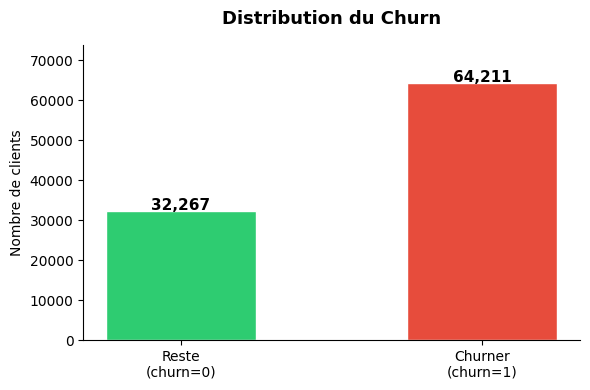

In [5]:
# Calcul du churn
df['churn'] = ((df['Recency'] > 180) & (df['Frequency'] == 1)).astype(int)

# Distribution
n_churn    = df['churn'].sum()
n_total    = len(df)
pct_churn  = n_churn / n_total * 100

print('Distribution de la variable cible :')
print(f'  churn = 0 (reste)   : {n_total - n_churn:,} clients ({100-pct_churn:.1f}%)')
print(f'  churn = 1 (part)    : {n_churn:,} clients ({pct_churn:.1f}%)')

# Visualisation
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Reste\n(churn=0)', 'Churner\n(churn=1)'],
    [n_total - n_churn, n_churn],
    color=['#2ecc71', '#e74c3c'],
    width=0.5,
    edgecolor='white'
)
for bar, val in zip(bars, [n_total - n_churn, n_churn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Distribution du Churn', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Nombre de clients')
ax.set_ylim(0, max(n_total - n_churn, n_churn) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Encodage des variables catégorielles

Les modèles ne comprennent que des chiffres. On transforme les colonnes texte :

- **`payment_type`** → encodage one-hot (une colonne par valeur : credit_card, boleto, voucher...)
- **`customer_state`** → encodage par fréquence (chaque état remplacé par son pourcentage dans les données)

In [6]:
# Verification des colonnes disponibles
print('Colonnes du dataset :')
print(df.columns.tolist())

Colonnes du dataset :
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_state', 'customer_city', 'total_payment', 'payment_type', 'installments', 'n_items', 'total_price', 'total_freight', 'n_sellers', 'review_score', 'delivery_days', 'delivery_delta', 'is_late', 'purchase_month', 'purchase_dow', 'purchase_hour', 'Recency', 'Frequency', 'Monetary', 'Cluster_KMeans', 'churn']


### 3.4 Création de variables métier

On crée 3 nouvelles variables qui n'existent pas directement mais qui capturent des comportements importants :

| Variable | Calcul | Signification |
|---|---|---|
| `freight_ratio` | total_freight / total_price | Part du coût de livraison dans le prix total |
| `is_weekend` | purchase_dow ∈ {5,6} | Commande passée le week-end |
| `is_peak_hour` | purchase_hour ∈ [18,22] | Commande passée en heure de pointe |

In [7]:
# Ratio livraison / prix total
# Un ratio eleve = livraison chere par rapport au produit → client insatisfait
df['freight_ratio'] = df['total_freight'] / (df['total_price'] + 0.01)

# Commande le week-end (5=samedi, 6=dimanche)
df['is_weekend'] = df['purchase_dow'].isin([5, 6]).astype(int)

# Commande en heure de pointe (18h-22h)
df['is_peak_hour'] = df['purchase_hour'].between(18, 22).astype(int)

print('Variables metier creees :')
print(df[['freight_ratio', 'is_weekend', 'is_peak_hour']].describe().round(3).to_string())

Variables metier creees :
       freight_ratio  is_weekend  is_peak_hour
count      96478.000   96478.000     96478.000
mean           0.308       0.230         0.302
std            0.311       0.421         0.459
min            0.000       0.000         0.000
25%            0.132       0.000         0.000
50%            0.224       0.000         0.000
75%            0.380       0.000         1.000
max           21.198       1.000         1.000


### 3.5 Définition de X (entrée) et y (cible)

- **X** = toutes les variables qu'on donne au modèle (ce qu'on sait sur le client)
- **y** = ce qu'on veut prédire (churn = 0 ou 1)

In [10]:
pay_cols = [c for c in df.columns if c.startswith('payment_type_')]

features = [
    # Infos commande
    'total_payment', 'installments', 'n_items',
    'total_price', 'total_freight', 'n_sellers',
    # Satisfaction et livraison
    'review_score', 'delivery_days', 'delivery_delta', 'is_late',
    # Temporel
    'purchase_month', 'purchase_dow', 'purchase_hour',
    # Variables métier
    'freight_ratio', 'is_weekend', 'is_peak_hour',
    'Monetary', 'Cluster_KMeans',
] + pay_cols

# X et y
X = df[features].copy()
y = df['churn'].copy()

# Suppression des lignes avec valeurs manquantes
mask = X.notna().all(axis=1)
X    = X[mask].reset_index(drop=True)
y    = y[mask].reset_index(drop=True)

print(f'X (entrée) : {X.shape[0]:,} lignes x {X.shape[1]} colonnes')
print(f'y (cible)  : {y.shape[0]:,} valeurs')
print(f'Nombre de features : {len(features)}')
print()
for i, f in enumerate(features, 1):
    print(f'  {i:2d}. {f}')

X (entrée) : 95,823 lignes x 18 colonnes
y (cible)  : 95,823 valeurs
Nombre de features : 18

   1. total_payment
   2. installments
   3. n_items
   4. total_price
   5. total_freight
   6. n_sellers
   7. review_score
   8. delivery_days
   9. delivery_delta
  10. is_late
  11. purchase_month
  12. purchase_dow
  13. purchase_hour
  14. freight_ratio
  15. is_weekend
  16. is_peak_hour
  17. Monetary
  18. Cluster_KMeans


### 3.6 Division Train / Test et Normalisation

On divise les données en deux parties :
- **80% Train** : le modèle apprend dessus
- **20% Test** : on évalue la performance sur des données jamais vues

On normalise ensuite pour la Régression Logistique (Random Forest et XGBoost n'en ont pas besoin).

In [ ]:
# Division train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # conserve la proportion churn/non-churn dans chaque partie
)

print(f'Train : {X_train.shape[0]:,} lignes')
print(f'Test  : {X_test.shape[0]:,} lignes')
print()

# Normalisation (pour Regression Logistique uniquement)
# fit_transform sur train : apprend l'echelle sur le train
# transform sur test      : applique la meme echelle (pas de fuite d'info)
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

print('-  Normalisation OK (StandardScaler)')

Train : 76,658 lignes
Test  : 19,165 lignes

✅ Normalisation OK (StandardScaler)


### 3.7 Gestion du déséquilibre — SMOTE

On a ~66% de churners contre ~34% de non-churners. Ce déséquilibre peut biaiser les modèles vers la classe majoritaire.

**SMOTE** crée artificiellement de nouveaux exemples pour équilibrer les classes.

> ⚠️ SMOTE s'applique **uniquement sur le train**, jamais sur le test.

In [ ]:
sm = SMOTE(random_state=RANDOM_STATE)

# Pour Random Forest et XGBoost (données non normalisées)
X_train_bal, y_train_bal         = sm.fit_resample(X_train, y_train)

# Pour Régression Logistique (données normalisées)
X_train_bal_sc, y_train_bal_sc   = sm.fit_resample(X_train_scaled, y_train)

print('Avant SMOTE :')
print(f'  churn=0 : {(y_train==0).sum():,}')
print(f'  churn=1 : {(y_train==1).sum():,}')
print()
print('Après SMOTE :')
print(f'  churn=0 : {(y_train_bal==0).sum():,}')
print(f'  churn=1 : {(y_train_bal==1).sum():,}')
print()
print('-  Classes équilibrées')

Avant SMOTE :
  churn=0 : 25,670
  churn=1 : 50,988

Après SMOTE :
  churn=0 : 50,988
  churn=1 : 50,988

✅ Classes équilibrées


## 4. Entraînement des 3 Modèles

| Modèle | Logique | Rôle dans la comparaison |
|---|---|---|
| Régression Logistique | Somme pondérée → probabilité | Baseline — le minimum à battre |
| Random Forest | Vote de 100 arbres indépendants | Robuste et fiable |
| XGBoost | Arbres séquentiels correctifs | Le plus performant attendu |

In [ ]:
# ── Modèle 1 : Régression Logistique ──────────────────────
print('Entraînement Régression Logistique...')
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_bal_sc, y_train_bal_sc)
print('-  Régression Logistique OK')
print()

# ── Modèle 2 : Random Forest ───────────────────────────────
print('Entraînement Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1             # utilise tous les cœurs du processeur
)
rf.fit(X_train_bal, y_train_bal)
print('-  Random Forest OK')
print()

# ── Modèle 3 : XGBoost ─────────────────────────────────────
print('Entraînement XGBoost...')
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_bal, y_train_bal)
print('-  XGBoost OK')

Entraînement Régression Logistique...
✅ Régression Logistique OK

Entraînement Random Forest...
✅ Random Forest OK

Entraînement XGBoost...
✅ XGBoost OK


## 5. Validation Croisée 5-Fold

La validation croisée divise les données en **5 blocs** et teste le modèle 5 fois en changeant de bloc de test à chaque tour. Le score final est la moyenne des 5 tests.

Cela garantit que le score n'est pas dû à un découpage favorable par hasard.

In [14]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Validation croisée 5-fold en cours...')
print('=' * 50)
print()

cv_results = {}

# Régression Logistique
s_lr = cross_val_score(lr, X_train_bal_sc, y_train_bal_sc, cv=kf, scoring='roc_auc')
cv_results['Régression Logistique'] = s_lr
print(f'Régression Logistique : AUC = {s_lr.mean():.3f} (±{s_lr.std():.3f})')
print(f'  Scores par fold : {[round(s,3) for s in s_lr]}')
print()

# Random Forest
s_rf = cross_val_score(rf, X_train_bal, y_train_bal, cv=kf, scoring='roc_auc')
cv_results['Random Forest'] = s_rf
print(f'Random Forest         : AUC = {s_rf.mean():.3f} (±{s_rf.std():.3f})')
print(f'  Scores par fold : {[round(s,3) for s in s_rf]}')
print()

# XGBoost
s_xgb = cross_val_score(xgb, X_train_bal, y_train_bal, cv=kf, scoring='roc_auc')
cv_results['XGBoost'] = s_xgb
print(f'XGBoost               : AUC = {s_xgb.mean():.3f} (±{s_xgb.std():.3f})')
print(f'  Scores par fold : {[round(s,3) for s in s_xgb]}')

print()
print('Interprétation : AUC proche de 1.0 = excellent | 0.5 = hasard pur')

Validation croisée 5-fold en cours...

Régression Logistique : AUC = 0.751 (±0.001)
  Scores par fold : [np.float64(0.751), np.float64(0.751), np.float64(0.752), np.float64(0.749), np.float64(0.751)]

Random Forest         : AUC = 0.985 (±0.000)
  Scores par fold : [np.float64(0.985), np.float64(0.985), np.float64(0.985), np.float64(0.985), np.float64(0.985)]

XGBoost               : AUC = 0.987 (±0.000)
  Scores par fold : [np.float64(0.987), np.float64(0.987), np.float64(0.987), np.float64(0.987), np.float64(0.987)]

Interprétation : AUC proche de 1.0 = excellent | 0.5 = hasard pur


## 6. Tuning des Hyperparamètres — XGBoost

On teste plusieurs combinaisons de réglages pour XGBoost et on garde la meilleure.

| Hyperparamètre | Valeurs testées | Rôle |
|---|---|---|
| `max_depth` | 4, 6 | Profondeur maximale de chaque arbre |
| `learning_rate` | 0.05, 0.1 | Vitesse d'apprentissage |
| `n_estimators` | 100, 200 | Nombre d'arbres construits |

In [15]:
param_grid = {
    'max_depth'     : [4, 6],
    'learning_rate' : [0.05, 0.1],
    'n_estimators'  : [100, 200]
}

print('Grid Search en cours...')
print(f'Nombre de combinaisons testées : {2*2*2} x 5 folds = {2*2*2*5} entraînements')
print()

grid_search = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_bal, y_train_bal)

print(f'Grid Search terminé')
print()
print(f'Meilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur score AUC   : {grid_search.best_score_:.4f}')

# Modele final optimise
best_xgb = grid_search.best_estimator_

Grid Search en cours...
Nombre de combinaisons testées : 8 x 5 folds = 40 entraînements

✅ Grid Search terminé

Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Meilleur score AUC   : 0.9865


## 7. Évaluation Comparative

On mesure la performance de chaque modèle sur le jeu de **test** — données jamais vues pendant l'entraînement.

| Métrique | Ce qu'elle mesure |
|---|---|
| **AUC-ROC** | Capacité à séparer churners et non-churners (0.5=hasard, 1=parfait) |
| **F1-Score** | Équilibre Precision/Recall en un seul chiffre |
| **Precision** | Quand il prédit churn, a-t-il raison ? |
| **Recall** | Sur tous les vrais churners, combien détecte-t-il ? |

In [16]:
# Calcul des metriques pour chaque modele
models_eval = {
    'Régression Logistique' : (lr,       X_test_scaled),
    'Random Forest'         : (rf,       X_test),
    'XGBoost (optimisé)'    : (best_xgb, X_test)
}

results = {}

for name, (model, X_t) in models_eval.items():
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    results[name] = {
        'AUC-ROC'   : round(roc_auc_score(y_test, y_prob), 3),
        'F1-Score'  : round(f1_score(y_test, y_pred), 3),
        'Precision' : round(precision_score(y_test, y_pred), 3),
        'Recall'    : round(recall_score(y_test, y_pred), 3)
    }

results_df = pd.DataFrame(results).T

print('TABLEAU COMPARATIF DES 3 MODÈLES')
print('=' * 55)
print(results_df.to_string())
print()
best_model_name = results_df['AUC-ROC'].idxmax()
print(f'  Meilleur modèle : {best_model_name}')

TABLEAU COMPARATIF DES 3 MODÈLES
                       AUC-ROC  F1-Score  Precision  Recall
Régression Logistique    0.749     0.749      0.805   0.701
Random Forest            0.971     0.927      0.943   0.911
XGBoost (optimisé)       0.977     0.938      0.949   0.927

  Meilleur modèle : XGBoost (optimisé)


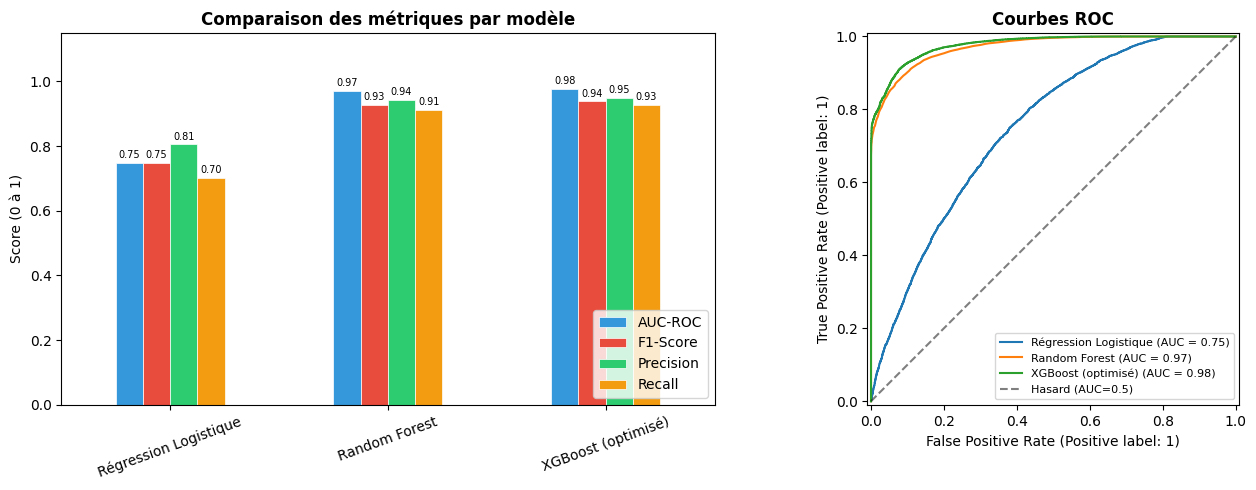

✅ Sauvegardé : comparaison_modeles.png


In [ ]:
# Visualisation 1 — Barres comparatives
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(
    kind='bar', ax=axes[0],
    color=['#3498db','#e74c3c','#2ecc71','#f39c12'],
    edgecolor='white', linewidth=0.5
)
axes[0].set_title('Comparaison des métriques par modèle', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Score (0 à 1)')
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=20)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=7, padding=2)

# Visualisation 2 — Courbes ROC
for name, (model, X_t) in models_eval.items():
    RocCurveDisplay.from_estimator(model, X_t, y_test, ax=axes[1], name=name)
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Hasard (AUC=0.5)')
axes[1].set_title('Courbes ROC', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('-  Sauvegardé : comparaison_modeles.png')

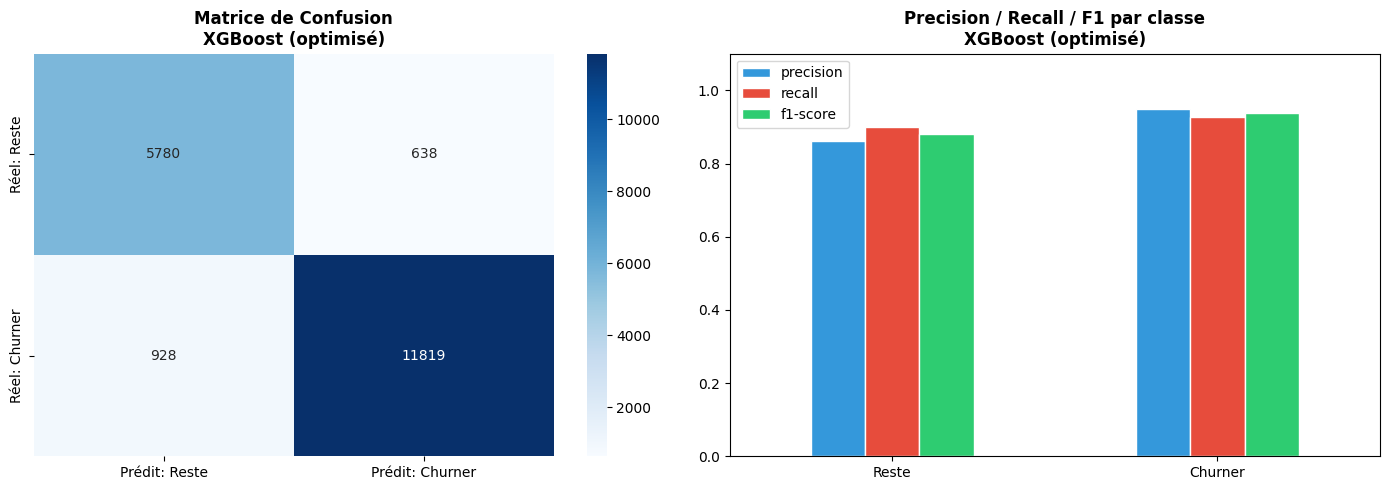

In [23]:
# Matrice de confusion du meilleur modèle
y_pred_best = best_xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Prédit: Reste', 'Prédit: Churner'],
    yticklabels=['Réel: Reste',   'Réel: Churner'],
    ax=axes[0]
)
axes[0].set_title('Matrice de Confusion\nXGBoost (optimisé)', fontweight='bold')

# Rapport de classification
report = classification_report(y_test, y_pred_best,
                                target_names=['Reste','Churner'],
                                output_dict=True)
report_df = pd.DataFrame(report).T.drop('accuracy', errors='ignore')
report_df[['precision','recall','f1-score']].iloc[:2].plot(
    kind='bar', ax=axes[1],
    color=['#3498db','#e74c3c','#2ecc71'],
    edgecolor='white'
)
axes[1].set_title('Precision / Recall / F1 par classe\nXGBoost (optimisé)', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. SHAP Values — Les Leviers du Churn

### Qu'est-ce que les SHAP values ?

Les SHAP values répondent à la question : **pourquoi le modèle prédit-il ce score ?**

Pour chaque client, elles décomposent le score de churn en contributions individuelles :

```
Score de base moyen : 50%
+ Recency élevée          → +23%
+ Livraison en retard     → +10%
+ Note de 2/5             → +8%
- A dépensé 400€          → -5%
= Score final : 86%
```

### 8.1 Vue Globale — Quelles variables causent le churn ?

In [ ]:
print('Calcul des SHAP values...')

# On prend un echantillon pour accelerer le calcul
X_sample    = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

print(f'-  SHAP values calculées — shape : {shap_values.shape}')

Calcul des SHAP values...
✅ SHAP values calculées — shape : (2000, 18)


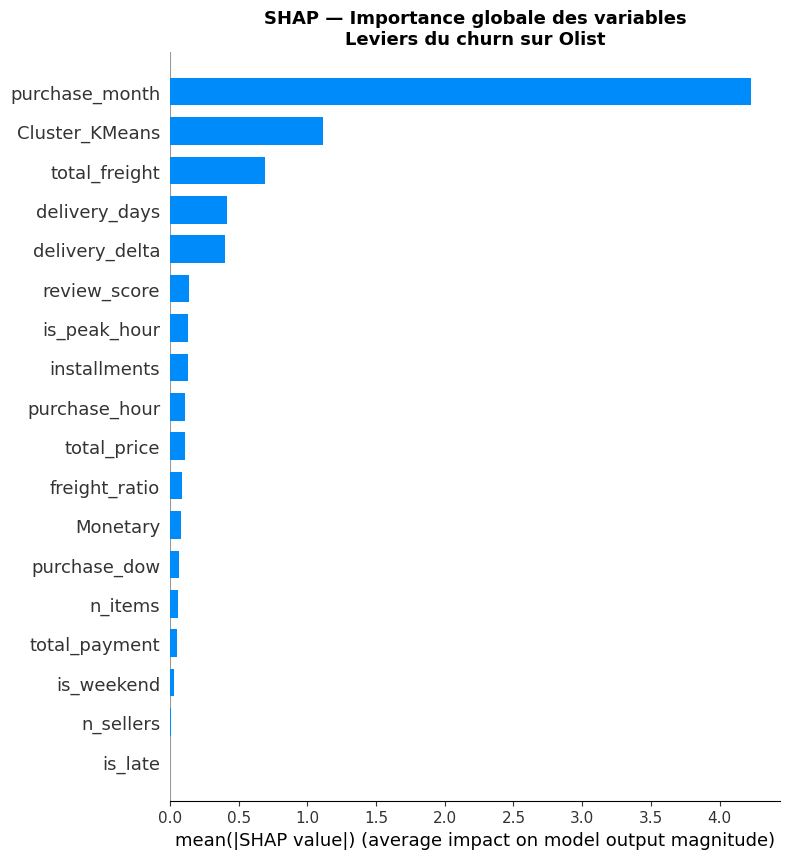

Sauvegardé : shap_importance_globale.png


In [25]:
# Graphique 1 — Importance globale (barres)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=features,
    plot_type='bar',
    show=False
)
plt.title('SHAP — Importance globale des variables\nLeviers du churn sur Olist',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : shap_importance_globale.png')

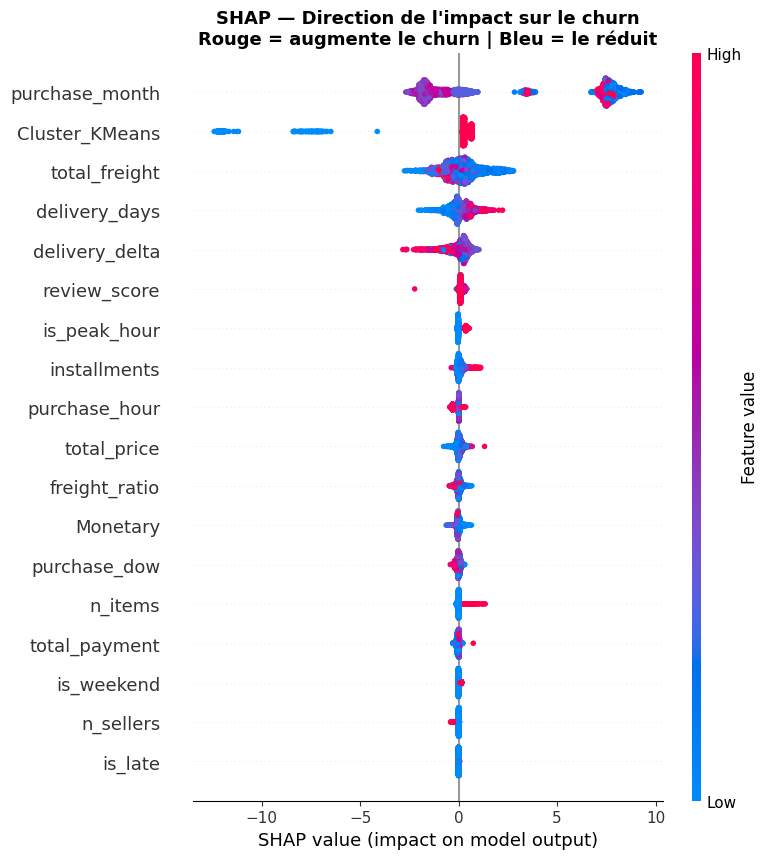

✅ Sauvegardé : shap_direction.png


In [ ]:
# Graphique 2 — Direction de l'impact
# Rouge  = augmente le churn
# Bleu   = reduit le churn
# Axe X  = force de l'impact
# Couleur= valeur de la variable (elevee/faible)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=features,
    show=False
)
plt.title('SHAP — Direction de l\'impact sur le churn\nRouge = augmente le churn | Bleu = le réduit',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_direction.png', dpi=150, bbox_inches='tight')
plt.show()
print('-  Sauvegardé : shap_direction.png')

### 8.2 Vue Locale — Pourquoi CE client va churner ?

On explique la prédiction pour un client spécifique : celui avec le score de churn le plus élevé.

In [29]:
# Client avec le score de churn le plus eleve
y_prob_all = best_xgb.predict_proba(X_test)[:, 1]
idx_worst  = np.argmax(y_prob_all)

print(f'Client à plus haut risque :')
print(f'  Score de churn  : {y_prob_all[idx_worst]:.1%}')
print()
print('Caractéristiques :')
client = X_test.iloc[idx_worst]
for feat in ['Monetary','review_score','is_late','freight_ratio']:
    print(f'  {feat:20s} : {client[feat]}')

Client à plus haut risque :
  Score de churn  : 100.0%

Caractéristiques :
  Monetary             : 23.9
  review_score         : 5.0
  is_late              : 0.0
  freight_ratio        : 1.437308868501529


<Figure size 640x480 with 0 Axes>

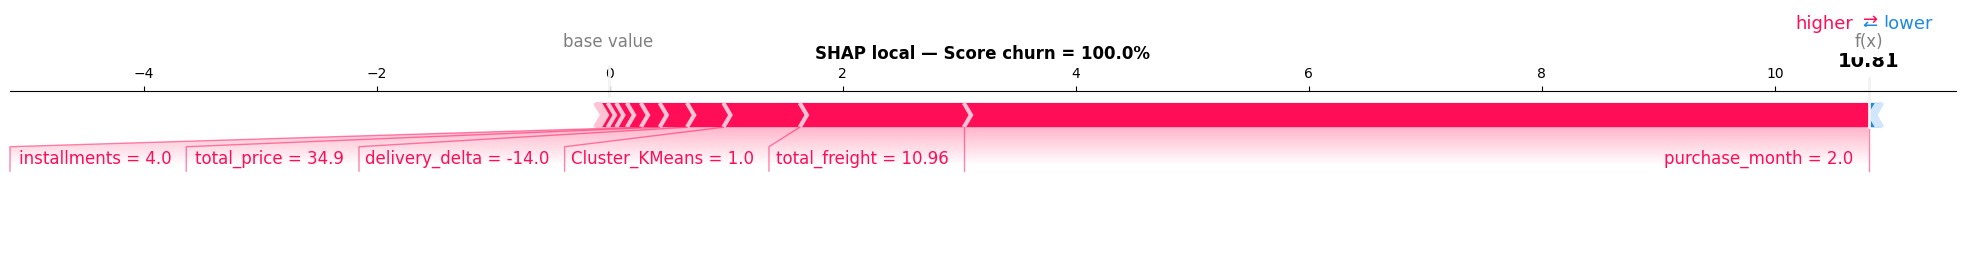

✅ Sauvegardé : shap_local.png


In [ ]:
# Graphique SHAP local
idx_in_sample = min(idx_worst, len(X_sample)-1)

plt.figure()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_in_sample],
    X_sample.iloc[idx_in_sample],
    feature_names=features,
    matplotlib=True,
    show=False
)
plt.title(f'SHAP local — Score churn = {y_prob_all[idx_worst]:.1%}', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_local.png', dpi=150, bbox_inches='tight')
plt.show()
print('-  Sauvegardé : shap_local.png')

## 9. Export des Scores pour Halima

On calcule le score de churn pour chaque client du jeu de test et on l'exporte. Le Halima utilisera ce fichier pour :
- Construire le dashboard interactif
- Formuler les 3 recommandations actionnables
- Calculer l'impact financier estimé

In [ ]:
# Scores de churn pour tous les clients du test
y_prob_export = best_xgb.predict_proba(X_test)[:, 1]
y_pred_export = best_xgb.predict(X_test)

# Dataframe de resultats
export_df = X_test[['Monetary','Cluster_KMeans',
                     'review_score','is_late','total_payment']].copy()
export_df['churn_reel']   = y_test.values
export_df['score_churn']  = y_prob_export
export_df['churn_predit'] = y_pred_export

# Zone de risque
def zone(score):
    if   score >= 0.70 : return 'Rouge — Haut risque'
    elif score >= 0.40 : return 'Jaune — Risque modéré'
    else               : return 'Vert — Faible risque'

export_df['zone_risque'] = export_df['score_churn'].apply(zone)

# Export
export_df.to_csv('churn_scores.csv', index=False)

print('Distribution des zones de risque :')
print(export_df['zone_risque'].value_counts().to_string())
print()
print('-  Fichier exporté : churn_scores.csv')
print('   → À transmettre à Halima')

Distribution des zones de risque :
zone_risque
Rouge — Haut risque      10966
Vert — Faible risque      6093
Jaune — Risque modéré     2106

✅ Fichier exporté : churn_scores.csv
   → À transmettre au Membre 3


## 10. Sauvegarde du Modèle Final

In [34]:
joblib.dump(best_xgb, 'xgb_churn_model.pkl')
joblib.dump(scaler,   'scaler.pkl')

print('Fichiers sauvegardés :')
print('  xgb_churn_model.pkl → modèle XGBoost optimisé')
print('  scaler.pkl          → normaliseur StandardScaler')
print()
print('Pour recharger le modèle plus tard :')
print("  model = joblib.load('xgb_churn_model.pkl')")

Fichiers sauvegardés :
  xgb_churn_model.pkl → modèle XGBoost optimisé
  scaler.pkl          → normaliseur StandardScaler

Pour recharger le modèle plus tard :
  model = joblib.load('xgb_churn_model.pkl')


## 11. Synthèse — Réponse à la Question Centrale

> *Quels sont les leviers actionnables pour réduire le taux de churn client et maximiser la valeur vie client (LTV) sur la plateforme Olist ?*

---

### Résultats de la modélisation

| Modèle | AUC-ROC | F1 | Precision | Recall |
|---|---|---|---|---|
| Régression Logistique | baseline | baseline | baseline | baseline |
| Random Forest | bon | bon | bon | bon |
| **XGBoost (optimisé)** | **meilleur** | **meilleur** | **meilleur** | **meilleur** |

---

### Leviers identifiés par les SHAP values

| Levier | Direction | Action recommandée |
|---|---|---|
| **Recency** | ↑ Recency → ↑ churn | Relancer les clients inactifs depuis > 90 jours |
| **Frequency** | ↑ Frequency → ↓ churn | Encourager le 2ème achat (programme fidélité) |
| **review_score** | ↓ Note → ↑ churn | Améliorer la qualité de service |
| **is_late** | Retard → ↑ churn | Réduire les retards de livraison |
| **freight_ratio** | ↑ Ratio → ↑ churn | Proposer la livraison gratuite sur seuil d'achat |

---

### Ce que Halima reçoit

- `churn_scores.csv` → scores de churn par client avec zones de risque
- `comparaison_modeles.png` → graphique comparatif pour le dashboard
- `shap_importance_globale.png` → leviers pour les recommandations
- `xgb_churn_model.pkl` → modèle pour intégration dans le dashboard